# Imports

In [12]:
pip install numpy scipy polars matplotlib numba xgboost scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [13]:
import numpy as np
from scipy import signal
import polars as pl
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import __version__ as xgboostVersion
from scipy import __version__ as scipyVersion
from matplotlib import __version__ as matplotlibVersion
from numba  import __version__ as numbaVersion

print("numpy", np.__version__)
print("scipy", scipyVersion)
print("Polars", pl.__version__)
print("matplotlib", matplotlibVersion)
print("numba", numbaVersion)
print("xgboost", xgboostVersion)


numpy 2.5.3
scipy 1.18.1
Polars 1.44.1
matplotlib 3.11.1
numba 0.67.0
xgboost 3.4.1


# Load the data

In [14]:
DEF_PATH = "Bonn-EEG-Dataset-main/"
sets = ["F", "N", "O", "S", "Z"]
sets = ["F", "O", "S"]

rows = []

count = 0
for s in sets:
    for i in range(1, 101):
        x = np.loadtxt(f"{DEF_PATH}Set_{s}/{s}{i:03d}.txt")
        row = {"set": s, "id": count, "signal": x}
        count += 1
        rows.append(row)

df = pl.DataFrame(rows)


mapping1 = {
    "Z": "Normal", 
    "O": "Normal",
    "N": "interictal", 
    "F": "interictal",
    "S": "ictal",
}

mapping2 = {
    "Z": 0, 
    "O": 0,
    "N": 1, 
    "F": 1,
    "S": 2,
}

df = df.with_columns(pl.col("set").replace(mapping1).alias("classe"), pl.col("set").replace(mapping2).cast(pl.Int64).alias("classe_index"))

print(df.head(), df.tail())
signals = np.array(df["signal"].to_list())


shape: (5, 5)
┌─────┬─────┬─────────────────────────┬────────────┬──────────────┐
│ set ┆ id  ┆ signal                  ┆ classe     ┆ classe_index │
│ --- ┆ --- ┆ ---                     ┆ ---        ┆ ---          │
│ str ┆ i64 ┆ list[f64]               ┆ str        ┆ i64          │
╞═════╪═════╪═════════════════════════╪════════════╪══════════════╡
│ F   ┆ 0   ┆ [34.0, 33.0, … 7.0]     ┆ interictal ┆ 1            │
│ F   ┆ 1   ┆ [60.0, 47.0, … 42.0]    ┆ interictal ┆ 1            │
│ F   ┆ 2   ┆ [26.0, 16.0, … -130.0]  ┆ interictal ┆ 1            │
│ F   ┆ 3   ┆ [-41.0, -42.0, … -13.0] ┆ interictal ┆ 1            │
│ F   ┆ 4   ┆ [13.0, 6.0, … 1.0]      ┆ interictal ┆ 1            │
└─────┴─────┴─────────────────────────┴────────────┴──────────────┘ shape: (5, 5)
┌─────┬─────┬───────────────────────────┬────────┬──────────────┐
│ set ┆ id  ┆ signal                    ┆ classe ┆ classe_index │
│ --- ┆ --- ┆ ---                       ┆ ---    ┆ ---          │
│ str ┆ i64 ┆ list[f64]   

# Spectral entropies

In [17]:
from utils import psd_prob, spectral_entropy, renyi_entropy, plot_entropy_distribution, k2_entropy

print(spectral_entropy(signals[0], 173.61), df.filter(pl.col("id") == 0)["classe"][0])
print(spectral_entropy(signals[190], 173.61), df.filter(pl.col("id") == 190)["classe"][0])
print(spectral_entropy(signals[299], 173.61), df.filter(pl.col("id") == 299)["classe"][0])

print("Embeding entropy")
print(k2_entropy(signals[190]), df.filter(pl.col("id") == 190)["classe"][0])
print(k2_entropy(signals[0]), df.filter(pl.col("id") == 0)["classe"][0])
print(k2_entropy(signals[299]), df.filter(pl.col("id") == 299)["classe"][0])

2.6197111544459712 interictal
3.356063396292473 Normal
2.7439445892177923 ictal
Embeding entropy
0.8520484631458015 Normal
0.7268066559112382 interictal
0.5145315329823273 ictal


In [18]:
entropy_df = df.lazy()
entropy_df = entropy_df.with_columns(
    pl.col("signal").map_elements(
        lambda s: spectral_entropy(s.to_numpy(), 173.61),
        return_dtype=pl.Float64,
    ).alias("spectral_entropy")
).with_columns(
    pl.col("signal").map_elements(
        lambda s: renyi_entropy(s.to_numpy(), 173.61, fmin = 20, fmax = 45),
        return_dtype=pl.Float64,
    ).alias("renyi_entropy")
).with_columns(
    pl.col("signal").map_elements(
        lambda s: k2_entropy(s.to_numpy()),
        return_dtype=pl.Float64,
    ).alias("K2_entropy")
)
entropy_df = entropy_df.collect()["K2_entropy", "spectral_entropy", "renyi_entropy", "id", "classe"]

entropy_df.describe()

statistic,K2_entropy,spectral_entropy,renyi_entropy,id,classe
str,f64,f64,f64,f64,str
"""count""",300.0,300.0,300.0,300.0,"""300"""
"""null_count""",0.0,0.0,0.0,0.0,"""0"""
"""mean""",NaN,2.918533,2.525317,149.5,null
"""std""",NaN,0.38677,0.310212,86.746758,null
"""min""",0.064233,1.967333,1.33312,0.0,"""Normal"""
"""25%""",0.344156,2.619711,2.365058,75.0,null
"""50%""",0.517498,2.898874,2.557378,150.0,null
"""75%""",0.724974,3.227492,2.723539,224.0,null
"""max""",2.197225,3.685945,3.368661,299.0,"""interictal"""


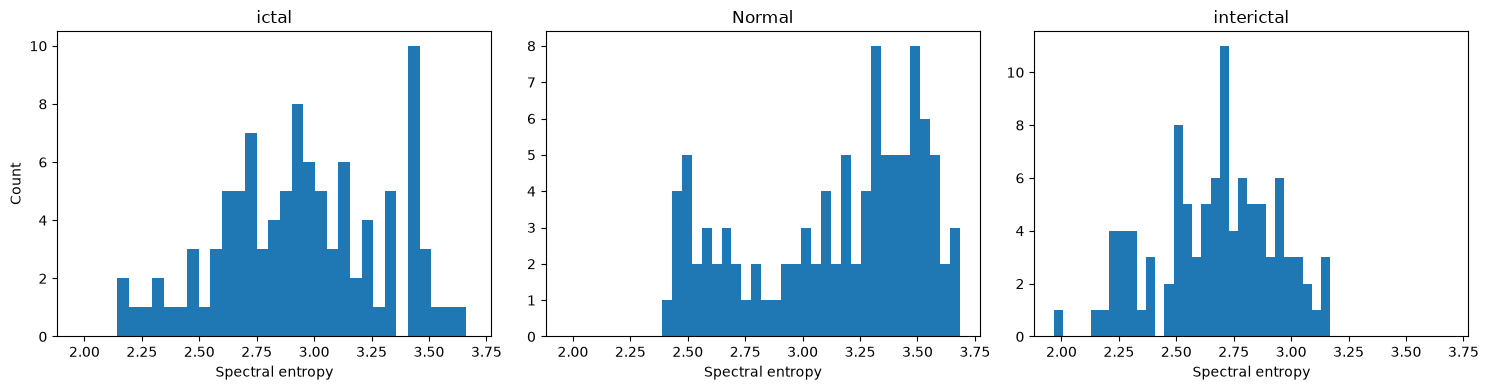

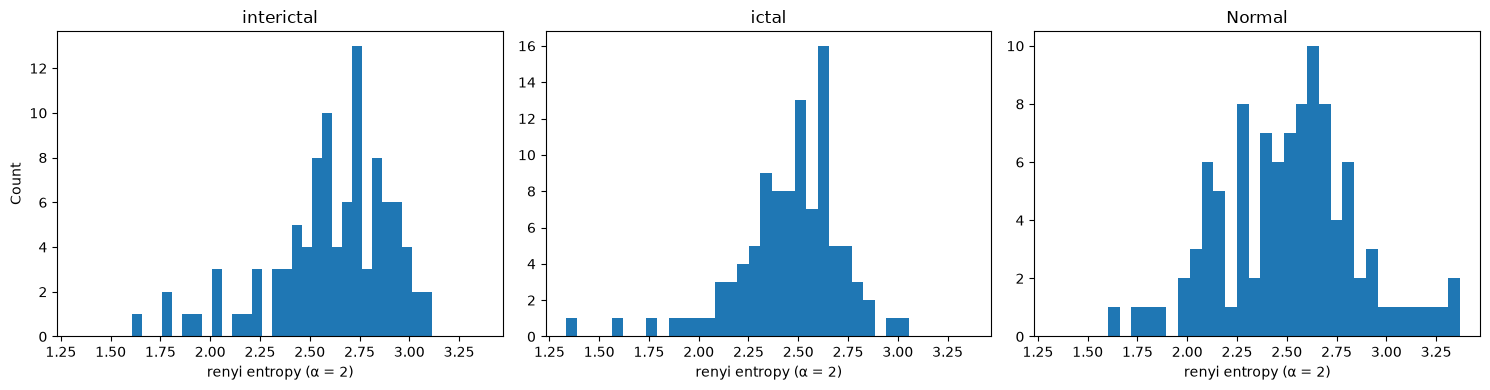

In [19]:
plot_entropy_distribution(entropy_df)
plot_entropy_distribution(entropy_df, value_col = "renyi_entropy", xlabel = "renyi entropy (⍺ = 2)")
print()

## embeding entropies

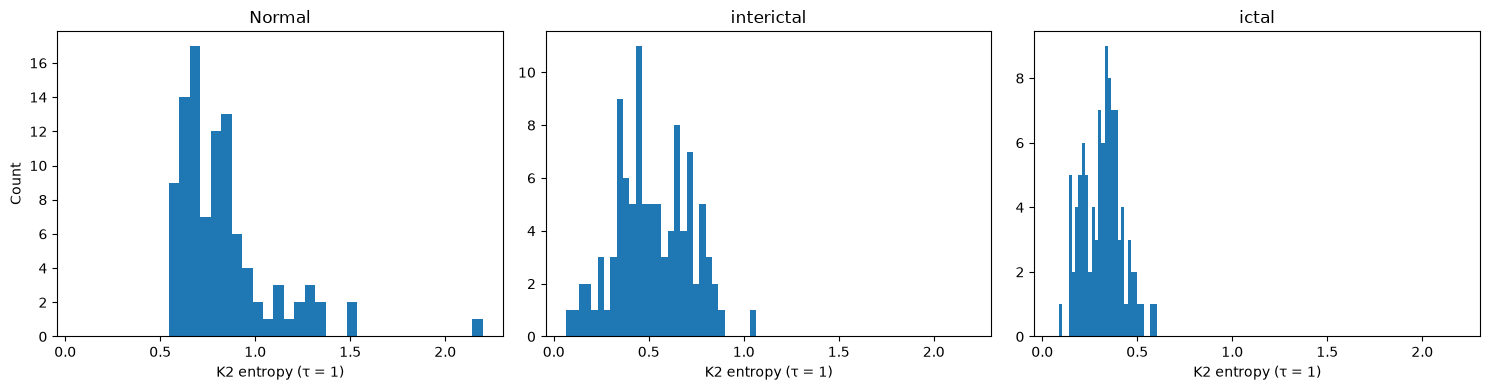

In [20]:
plot_entropy_distribution(entropy_df, value_col = "K2_entropy", xlabel = "K2 entropy (τ = 1)")
print()


## Test clasification

In [21]:
tempMap = {
    "Normal" : 0,
    "interictal" : 1,
    "ictal" : 2
}


In [22]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

X = entropy_df.select(["K2_entropy"]).to_numpy()
y = entropy_df["classe"].replace(tempMap).cast(float).to_numpy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
scores = cross_val_score(XGBClassifier(), X, y, cv=cv, scoring="accuracy")
print(f"mean acc: {scores.mean():.3f} ± {scores.std():.3f}")

mean acc: 0.507 ± 0.085


In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

X = entropy_df.select(["spectral_entropy"]).to_numpy()
y = entropy_df["classe"].replace(tempMap).cast(float).to_numpy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
scores = cross_val_score(XGBClassifier(), X, y, cv=cv, scoring="accuracy")
print(f"mean acc: {scores.mean():.3f} ± {scores.std():.3f}")

mean acc: 0.497 ± 0.114


In [24]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

X = entropy_df.select(["renyi_entropy"]).to_numpy()
y = entropy_df["classe"].replace(tempMap).cast(float).to_numpy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
scores = cross_val_score(XGBClassifier(), X, y, cv=cv, scoring="accuracy")
print(f"mean acc: {scores.mean():.3f} ± {scores.std():.3f}")

mean acc: 0.343 ± 0.072
